# SHAP for Random Forests - Regression

### Import require modules

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import shap
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

### Import and setup data

In [5]:
wine = pd.read_csv('wine.csv')
y = wine['quality']
X = wine.drop(columns=['quality'])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Develop and fit Random Forest Regressor Model

In [7]:
model = RandomForestRegressor(random_state=42)

In [8]:
model = model.fit(X_train, y_train)

In [11]:
y_pred = model.predict(X_test)

In [18]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {round(mae,4)}")
print(f"RMSE: {round(rmse,4)}")

MAE: 0.4401
RMSE: 0.6095


I need to compare these and SHAP result effects against other models

## SHAP Values

In [19]:
explainer = shap.Explainer(model, X_train)

In [21]:
shap_values = explainer(X_test, check_additivity=False)

100%|===================| 1613/1617 [00:56<00:00]        

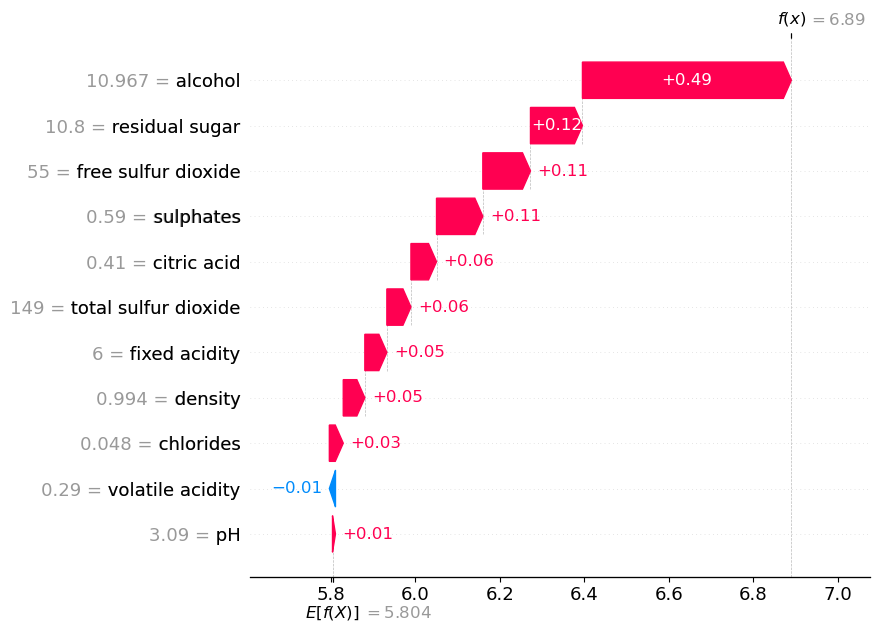

In [25]:
shap.plots.waterfall(shap_values[0], max_display=12)

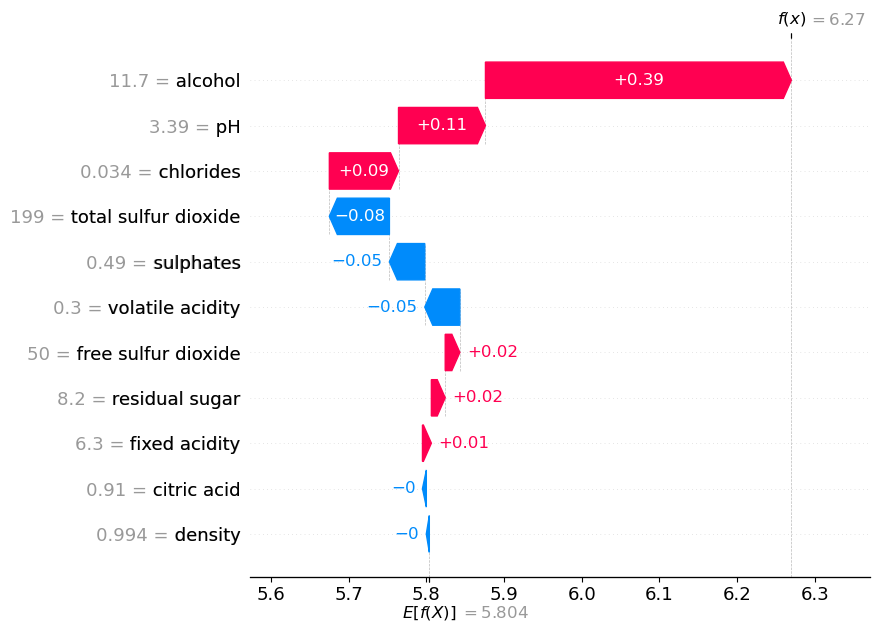

In [26]:
shap.plots.waterfall(shap_values[5], max_display=12)

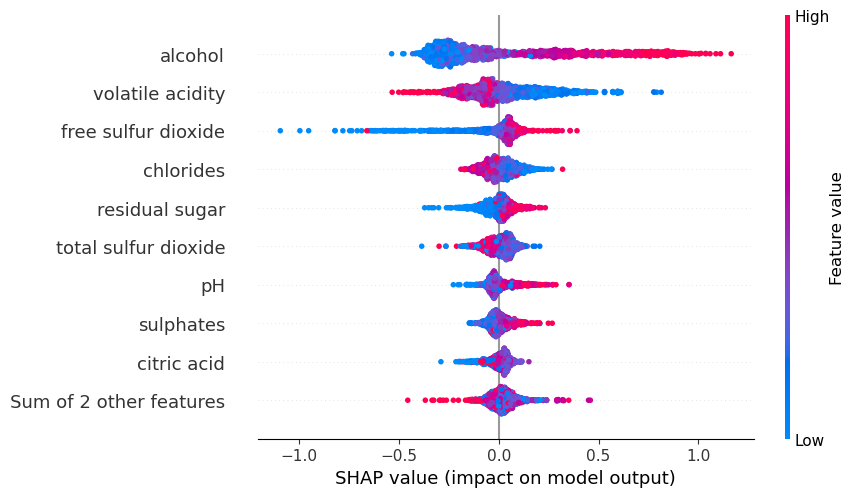

In [27]:
shap.plots.beeswarm(shap_values)

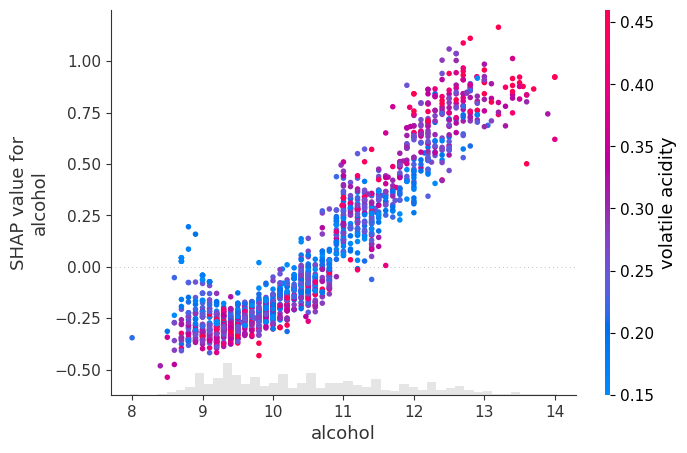

In [29]:
shap.plots.scatter(shap_values[:,"alcohol"], color=shap_values)

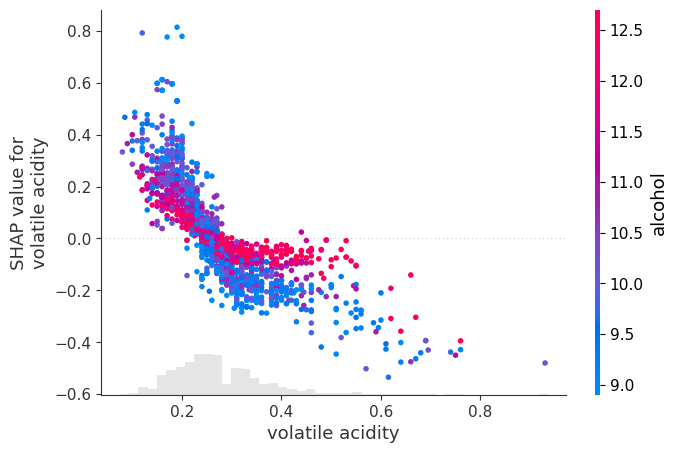

In [30]:
shap.plots.scatter(shap_values[:,"volatile acidity"], color=shap_values)

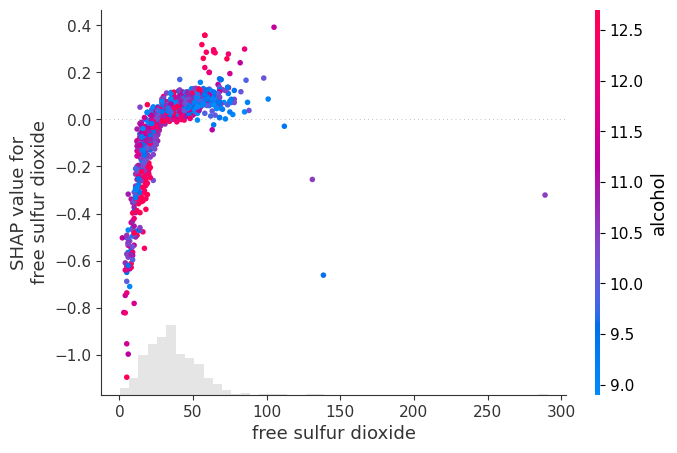

In [31]:
shap.plots.scatter(shap_values[:,"free sulfur dioxide"], color=shap_values)

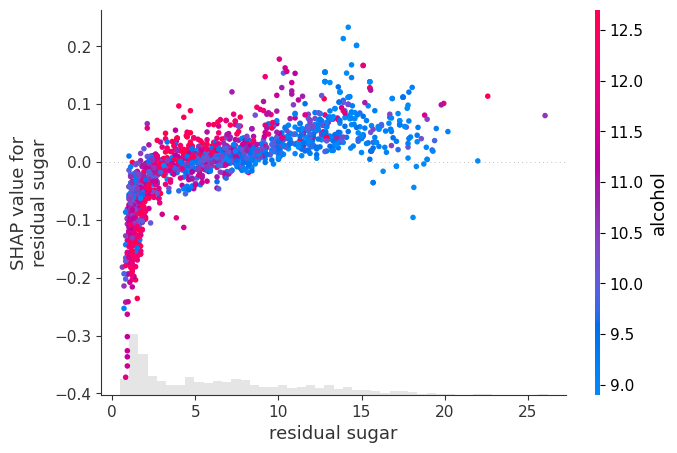

In [32]:
shap.plots.scatter(shap_values[:,"residual sugar"], color=shap_values)